In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

In [3]:
student_data = pd.read_csv("student-data.csv")
student_data


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,passed
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,no
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,no
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,yes
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,yes
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,no,no,5,5,4,4,5,4,11,no
391,MS,M,17,U,LE3,T,3,1,services,services,...,yes,no,2,4,5,3,4,2,3,yes
392,MS,M,21,R,GT3,T,1,1,other,other,...,no,no,5,5,3,3,3,3,3,no
393,MS,M,18,R,LE3,T,3,2,services,other,...,yes,no,4,4,1,3,4,5,0,yes


In [4]:
student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

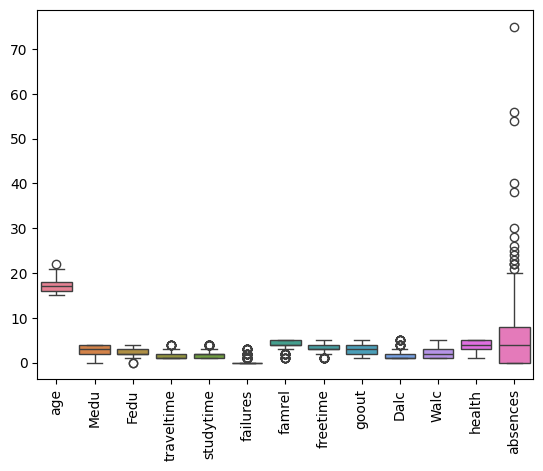

In [5]:
sns.boxplot(student_data)
plt.xticks(rotation=90)
plt.show()

In [6]:
student_data.select_dtypes(include=['object']).columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic', 'passed'],
      dtype='object')

Preprocessing

In [7]:
# seperate x and y
x = student_data.drop(['passed'], axis=1)
y = student_data['passed']

In [8]:
#Train and split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2, random_state=42)

In [9]:
cate_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic',]
num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

In [10]:
# Create the preprocessing pipeline using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cate_cols),
        ('num', StandardScaler(), num_cols)
    ]
)


In [11]:
# preprocessing pipeline
preprocessing_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

In [12]:
#Fit and trnsform training data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train_processed = preprocessing_pipeline.fit_transform(x_train)
x_test_processed  = preprocessing_pipeline.transform(x_test)

In [13]:
#Logistic Regression model
lr_model =LogisticRegression(max_iter=1000)
lr_model.fit(x_train_processed,y_train)
y_pred_lr_model=lr_model.predict(x_test_processed)

In [14]:
from sklearn.metrics import confusion_matrix,precision_score
from sklearn.metrics import accuracy_score,f1_score
from sklearn.metrics import recall_score

In [15]:
print(confusion_matrix(y_test, y_pred_lr_model))
print('Accuracy is:', accuracy_score(y_test, y_pred_lr_model))
print('Precision is:', precision_score(y_test, y_pred_lr_model,pos_label='yes'))
print('F1 score is:', f1_score(y_test, y_pred_lr_model,pos_label='yes'))
print('Recall score is:', recall_score(y_test, y_pred_lr_model,pos_label='yes'))

[[12 15]
 [ 6 46]]
Accuracy is: 0.7341772151898734
Precision is: 0.7540983606557377
F1 score is: 0.8141592920353983
Recall score is: 0.8846153846153846
